<a href="https://colab.research.google.com/github/akuntugasrapon/RafkiAhmadPagamanda_2311533016_ML2526/blob/main/Praktikum2/BernoulliNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [135]:
dummy_data = {
'Outlook': ['sunny','sunny','overcast','rainy','rainy','rainy','overcast','sunny','sunny','rainy','sunny','overcast','overcast','rainy'],
'Temperature':[85,80,83,70,68,65,64,72,69,75,75,72,81,71],
'Humidity':[85,90,78,96,80,70,65,95,70,80,70,90,75,80],
'Wind':[False,True,False,False,False,True,True,False,False,False,True,True,False,True],
'Play':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(dummy_data)

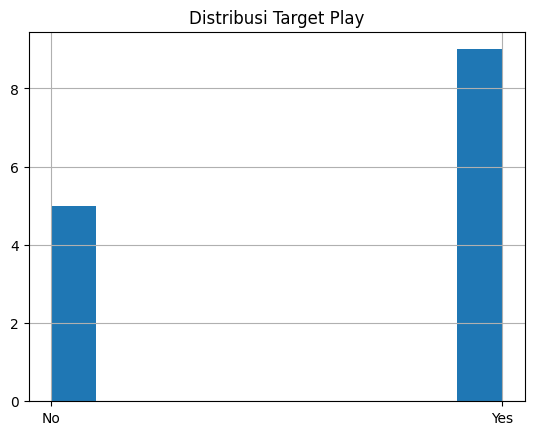

In [136]:
df["Play"].hist()

plt.title("Distribusi Target Play")
plt.show()

In [137]:
df = pd.get_dummies(df, columns=['Outlook'], dtype=int)

df.head()

,Temperature,Humidity,Wind,Play,Outlook_overcast,Outlook_rainy,Outlook_sunny
0,85,85,False,No,0,0,1
1,80,90,True,No,0,0,1
2,83,78,False,Yes,1,0,0
3,70,96,False,Yes,0,1,0
4,68,80,False,Yes,0,1,0


In [138]:
df['Wind'] = df['Wind'].astype(int)

df['Play'] = (df['Play'] == 'Yes').astype(int)

In [139]:
df['Temperature_cat'] = np.where(df['Temperature'] > 80, 'Hot', 'Warm')

In [140]:
df['Humidity_cat'] = np.where(df['Humidity'] > 75, 'Humid', 'Dry')

In [141]:
one_hot = pd.get_dummies(
    df[['Temperature_cat','Humidity_cat']],
    drop_first=True,
    dtype=int
)

df = pd.concat([one_hot, df], axis=1)

df = df.drop(columns=[
    'Temperature',
    'Humidity',
    'Temperature_cat',
    'Humidity_cat'
])

df.head()

,Temperature_cat_Warm,Humidity_cat_Humid,Wind,Play,Outlook_overcast,Outlook_rainy,Outlook_sunny
0,0,1,0,0,0,0,1
1,1,1,1,0,0,0,1
2,0,1,0,1,1,0,0
3,1,1,0,1,0,1,0
4,1,1,0,1,0,1,0


In [142]:
X = df.drop(columns='Play')
y = df['Play']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=False
)

In [143]:
model = BernoulliNB()

model.fit(X_train, y_train)

BernoulliNB()

In [144]:
y_pred = model.predict(X_test)

In [145]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6


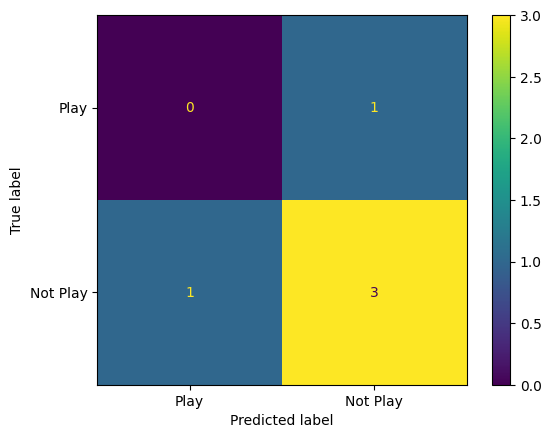

In [146]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Play","Not Play"]
)

disp.plot()

plt.show()